# ML Homework 2 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW1.ipynb" to "HW1_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

# [HW 2-1] Feature Extraction

Extract features from EXAMPLE DATASET according to following instructions:

1. Load 60 normal data and 60 abnormal data (Normal_1 ~ 60, Abnormal_1 ~ 60)
2. Extract features from acceleration and voltage signal (EXCLUDING current)
3. Extract 3 types of feature: Max, Min, Mean
4. Extract features from ONLY FREQUENCY (NOT Time) domains (WT coefficients)
5. Set the MOTHER WAVELET to 'sym3'
6. Set the wavelet decomposition level to 4


* Number of features: 3 features * 2 sensors * 4 WT levels = 24 features (per data)

* Refer to ML3_Code1

In [1]:
!pip install PyWavelets
import pandas as pd
import numpy as np
import scipy.stats as sp
import pywt

# Declare the size of feature dataset
NoOfData    = 60
NoOfSensor  = 2
NoOfFeature = 3

# Load raw dataset (120 files)

for i in range(NoOfData):

    temp_path1 = f'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Normal_{i+1}?raw=true'   # File path of temporary normal data
    temp_path2 = f'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset/Abnormal_{i+1}?raw=true' # File path of temporary abnormal data

    exec(f"Normal_{i+1}   = pd.read_csv(temp_path1 , sep=',' , header=None)")
    exec(f"Abnormal_{i+1} = pd.read_csv(temp_path2 , sep=',' , header=None)")


# Set wavelet transform options
MotherWavelet = pywt.Wavelet('sym3')   # Mother wavelet
Level   = 4                            # Wavelet decomposition level

# Create empty(0) arrays for normal/abnormal feature dataset
FreqFeature_Normal   = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))
FreqFeature_Abnormal = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))
# Frequency domain feature extraction
for i in range(NoOfData):

    # Only sensor signals
    # Assuming:
    # Column 0 = time
    # Column 1 = acceleration
    # Column 2 = voltage
    # Column 3 = current (EXCLUDED)

    exec(f"temp_data1 = Normal_{i+1}.iloc[:,1:3]")   # accel, voltage
    exec(f"temp_data2 = Abnormal_{i+1}.iloc[:,1:3]")

    # Wavelet decomposition
    Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)
    Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)

    for j in range(NoOfSensor):

        for k in np.arange(Level):
            coef1 = Coef1[Level-k]   # Detail coefficients
            coef2 = Coef2[Level-k]

            row_index = NoOfFeature*Level*j + NoOfFeature*k

            # ---------------- Normal ----------------
            FreqFeature_Normal[row_index + 0, i] = np.max(coef1[:,j])
            FreqFeature_Normal[row_index + 1, i] = np.min(coef1[:,j])
            FreqFeature_Normal[row_index + 2, i] = np.mean(coef1[:,j])

            # ---------------- Abnormal ----------------
            FreqFeature_Abnormal[row_index + 0, i] = np.max(coef2[:,j])
            FreqFeature_Abnormal[row_index + 1, i] = np.min(coef2[:,j])
            FreqFeature_Abnormal[row_index + 2, i] = np.mean(coef2[:,j])

print(FreqFeature_Normal.shape)
print(FreqFeature_Abnormal.shape)

# Result
FreqFeature = np.concatenate([FreqFeature_Normal, FreqFeature_Abnormal] , axis=1)
print(FreqFeature.shape)
#print(FreqFeature)

(24, 60)
(24, 60)
(24, 120)


# [HW2-2]

Reduce demension of the above featureset (12-D) to 2-D based on t-SNE and Visualize it.

* Don't need to select features
* Refer to ML4_Code2

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 120 samples in 0.001s...
[t-SNE] Computed neighbors for 120 samples in 0.056s...
[t-SNE] Computed conditional probabilities for sample 120 / 120
[t-SNE] Mean sigma: 1.870354
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.065197
[t-SNE] KL divergence after 750 iterations: 0.337385


t-SNE done! Time elapsed: 1.3027534484863281 seconds




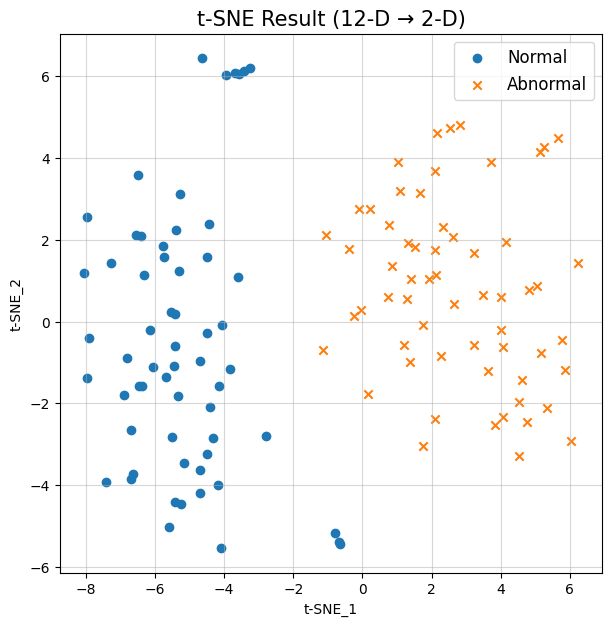

In [2]:
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Data Standardization
FeatureData = pd.DataFrame(FreqFeature).T
Feature_std = StandardScaler().fit_transform(FeatureData)
pd.DataFrame(Feature_std)

# t-SNE Implementation
dim = 2
time_start = time.time()

tsne = TSNE(n_components=dim,
            verbose=1,
            perplexity=30,   # good for 120 samples
            n_iter=1000,
            random_state=10) #trying different random_state instead of 1

tsne_results = tsne.fit_transform(Feature_std)

print('\n\nt-SNE done! Time elapsed: {} seconds\n\n'
      .format(time.time() - time_start))

pd.DataFrame(tsne_results)

# Visualization of t-SNE Result

NoOfData =int(Feature_std.shape[0]/2)  # 60 Normal, 60 Abnormal

plt.figure(figsize=(7,7))

# Normal
plt.scatter(tsne_results[:NoOfData,0],
            tsne_results[:NoOfData,1],
            marker='o',
            label='Normal')

# Abnormal
plt.scatter(tsne_results[NoOfData:,0],
            tsne_results[NoOfData:,1],
            marker='x',
            label='Abnormal')

plt.title('t-SNE Result (12-D → 2-D)', fontsize=15)
plt.grid(alpha=0.5)
plt.legend(fontsize=12)
plt.xlabel('t-SNE_1')
plt.ylabel('t-SNE_2')

plt.show()




## ML3 and ML4 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML3 and ML4.

---

ML3 focuses on transforming raw sensor signals into meaningful numerical features and selecting the most informative ones. First, statistical features are extracted from both time-domain signals and frequency-domain signals using wavelet decomposition. This converts complex raw data into structured feature vectors suitable for machine learning. Then, feature selection is performed using p-values to rank features based on how well they distinguish between normal and abnormal conditions, keeping only the most significant ones. ML4 then reduces the dimensionality of these selected features for visualization and analysis. PCA is used as a linear method to project the data into lower dimensions while preserving overall variance, whereas t-SNE is a nonlinear method that emphasizes local structure and is especially useful for visualizing class separation.

---

### Q2. What skills did you have to develop to accomplish this project?

---

Raw signal data

Feature extraction

Statistical testing

Dimensionality reduction

Visualization

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Turning raw signals into features

Applying statistical tests

Reducing dimensions (PCA, t-SNE)

Visualizing results

---

### Q4. What challenges did you encounter in completing the project?

---

Raw signal processing

Large numbers of features

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

One challenge was understanding raw signal processing, especially wavelet decomposition and feature extraction. Another difficulty was handling the large number of features, which made the data complex and harder to interpret. I overcame these challenges by reviewing the underlying concepts, testing the code step-by-step, and using feature selection and dimensionality reduction techniques to simplify and better understand the dat

---